# 03 Outlier Analysis

This notebook reviews extreme values before imputation and feature engineering. It produces:

- CSV summary in `../interim`
- Markdown report in `../reports`
- Outlier figures in `../figures`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_DIR = Path("..").resolve()
RAW_DIR = DATASET_DIR / "raw"
INTERIM_DIR = DATASET_DIR / "interim"
REPORTS_DIR = DATASET_DIR / "reports"
FIGURES_DIR = DATASET_DIR / "figures"

for directory in [INTERIM_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "GiveMeSomeCredit-training.csv"
TEST_PATH = RAW_DIR / "GiveMeSomeCredit-testing.csv"

In [3]:
train_df = pd.read_csv(TRAIN_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [4]:
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
outlier_summary = train_df[numeric_cols].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]).T
outlier_summary

,0.00,0.01,0.05,0.25,0.50,0.75,0.95,0.99,1.00
SeriousDlqin2yrs,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.0
RevolvingUtilizationOfUnsecuredLines,0.0,0.0,0.000000,0.029867,0.154181,0.559046,1.0,1.092956,50708.0
age,0.0,24.0,29.000000,41.000000,52.000000,63.000000,78.0,87.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,4.000000,98.0
DebtRatio,0.0,0.0,0.004329,0.175074,0.366508,0.868254,2449.0,4979.040000,329664.0
MonthlyIncome,0.0,0.0,1300.000000,3400.000000,5400.000000,8249.000000,14587.6,25000.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,0.0,0.0,2.000000,5.000000,8.000000,11.000000,18.0,24.000000,58.0
NumberOfTimes90DaysLate,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,3.000000,98.0
NumberRealEstateLoansOrLines,0.0,0.0,0.000000,0.000000,1.000000,2.000000,3.0,4.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,2.000000,98.0


In [5]:
watch_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
]

train_df[watch_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.0,0.000000,0.154181,1.0,1.092956,50708.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.0,0.004329,0.366508,2449.0,4979.040000,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,0.0,1300.000000,5400.000000,14587.6,25000.000000,3008750.0
age,150000.0,52.295207,14.771866,0.0,24.0,29.000000,52.000000,78.0,87.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.0,0.000000,0.000000,2.0,4.000000,98.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.0,0.000000,0.000000,1.0,2.000000,98.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.0,0.000000,0.000000,1.0,3.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.0,0.000000,1.000000,3.0,4.000000,54.0


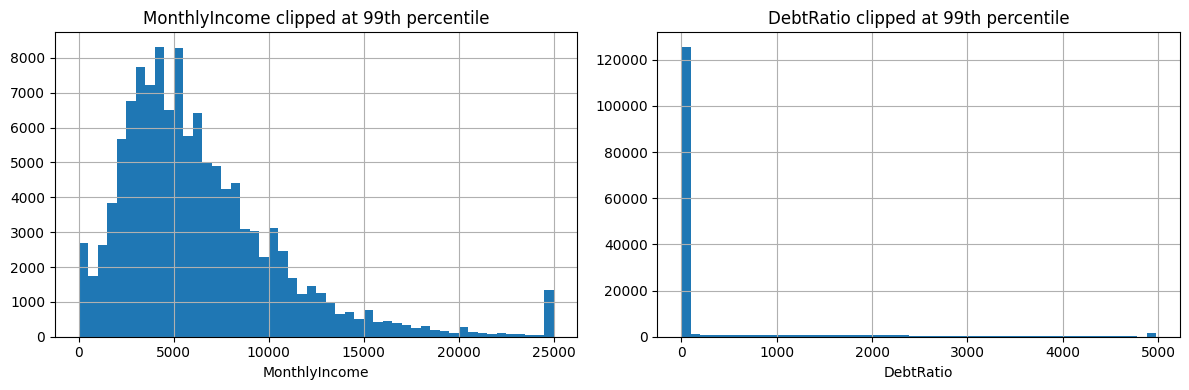

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["MonthlyIncome"].dropna().clip(upper=train_df["MonthlyIncome"].quantile(0.99)).hist(ax=axes[0], bins=50)
axes[0].set_title("MonthlyIncome clipped at 99th percentile")
axes[0].set_xlabel("MonthlyIncome")

train_df["DebtRatio"].clip(upper=train_df["DebtRatio"].quantile(0.99)).hist(ax=axes[1], bins=50)
axes[1].set_title("DebtRatio clipped at 99th percentile")
axes[1].set_xlabel("DebtRatio")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_income_debtratio.png", dpi=150)
plt.show()

In [7]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in delinquency_cols:
    print(f"\n{col}")
    print(train_df[col].value_counts().sort_index().tail(12))


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
4     747
5     342
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
1     5731
2     1118
3      318
4      105
5       34
6       16
7        9
8        2
9        1
11       1
96       5
98     264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
7      38
8      21
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64


In [8]:
review_flags = pd.DataFrame({
    "age_le_zero_train": [(train_df["age"] <= 0).sum()],
    "revolving_util_gt_1_train": [(train_df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()],
    "debt_ratio_gt_1_train": [(train_df["DebtRatio"] > 1).sum()],
    "monthly_income_zero_train": [(train_df["MonthlyIncome"] == 0).sum()],
    "monthly_income_missing_train": [train_df["MonthlyIncome"].isna().sum()],
})

review_flags

,age_le_zero_train,revolving_util_gt_1_train,debt_ratio_gt_1_train,monthly_income_zero_train,monthly_income_missing_train
0,1,3321,35137,1634,29731


In [9]:
outlier_summary.to_csv(INTERIM_DIR / "outlier_summary.csv")

report_text = f"""# Outlier Analysis

## Review Flags

| Check | Count |
|---|---:|
| age <= 0 | {(train_df['age'] <= 0).sum():,} |
| Revolving utilization > 1 | {(train_df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum():,} |
| Debt ratio > 1 | {(train_df['DebtRatio'] > 1).sum():,} |
| Monthly income = 0 | {(train_df['MonthlyIncome'] == 0).sum():,} |
| Monthly income missing | {train_df['MonthlyIncome'].isna().sum():,} |

## Decision

Keep the first pipeline conservative. Do not delete or cap aggressively yet. Preserve suspicious values and create derived flags during feature engineering.
"""

(REPORTS_DIR / "outlier_analysis.md").write_text(report_text, encoding="utf-8")
print("Saved outlier CSV, report, and figure.")

Saved outlier CSV, report, and figure.
